# Simple MNIST Neural Network

In this notebook, I implemented a simple two-layer neural network and trained it on the MNIST digit recognizer dataset. It's meant to be a training exercise, through which I can understand the underlying math of neural networks better.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# Importing data with pandas
data = pd.read_csv('MNIST.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Conversion to array
data = np.array(data)
print(f"Data shape :{data.shape}")
m, n = data.shape

# Data shuffle (Data will be shuffled for every new experiments)
np.random.shuffle(data)

# Spliting data and transporsing it
# Test data
data_dev = data[0:1000].T
y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

# Train data
data_train = data[1000:m].T
y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.

Data shape :(42000, 785)


### Essential math for a simple NN

This NN will have a simple two-layer architecture. Input layer $A^{[0]}$ will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer $A^{[1]}$ will have 10 units with ReLU activation, and finally our output layer $A^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**Forward propagation**

1st layer -> 2nd layer -> output layer

1st layer:

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = g_{\text{ReLU}}(Z^{[1]}))$$

2nd layer:

$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = g_{\text{softmax}}(Z^{[2]})$$

**Backward propagation**

output layer -> 2nd layer -> 1st layer

2nd layer:

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}}$$

1st layer:

$$dZ^{[1]} = W^{[2]T} dZ^{[2]} .* g^{[1]\prime} (z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} A^{[0]T}$$
$$dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Parameter updates**

Gradient descent with learning rate $\alpha$:

$$W^{[2]} := W^{[2]} - \alpha dW^{[2]}$$
$$b^{[2]} := b^{[2]} - \alpha db^{[2]}$$
$$W^{[1]} := W^{[1]} - \alpha dW^{[1]}$$
$$b^{[1]} := b^{[1]} - \alpha db^{[1]}$$

**Vars and shapes**

Forward prop

- $A^{[0]} = X$: 784 x m
- $Z^{[1]} \sim A^{[1]}$: 10 x m
- $W^{[1]}$: 10 x 784 (as $W^{[1]} A^{[0]} \sim Z^{[1]}$)
- $B^{[1]}$: 10 x 1
- $Z^{[2]} \sim A^{[2]}$: 10 x m
- $W^{[1]}$: 10 x 10 (as $W^{[2]} A^{[1]} \sim Z^{[2]}$)
- $B^{[2]}$: 10 x 1

Backprop

- $dZ^{[2]}$: 10 x m ($~A^{[2]}$)
- $dW^{[2]}$: 10 x 10
- $dB^{[2]}$: 10 x 1
- $dZ^{[1]}$: 10 x m ($~A^{[1]}$)
- $dW^{[1]}$: 10 x 10
- $dB^{[1]}$: 10 x 1

In [22]:
''' Essential functions '''

# Initiating parameters with random values
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prob(W1, b1, W2, b2, X):
    # 1st layer
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    # 2nd layer
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

def one_hot(y):
    one_hot_y = np.zeros((y.size, y.max() + 1))
    one_hot_y[np.arange(y.size), y] = 1
    one_hot_y = one_hot_y.T
    return one_hot_y

# Derivative of ReLU
def deriv_ReLU(Z):
    return Z > 0

def back_prob(Z1, A1, Z2, A2, W2, X, y):
    m = y.size
    one_hot_y = one_hot(y)
    
    # 2nd layer
    dZ2 = A2 - one_hot_y
    dW2 = (1/m) * dZ2.dot(A1.T)
    db2 = (1/m) * np.sum(dZ2)
    # 1st layer
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = (1/m) * dZ1.dot(X.T)
    db1 = (1/m) * np.sum(dZ1)
    
    return dW1, db1, dW2, db2

# Gradient function
def upadate_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [23]:
def get_prediction(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, y):
    # print(predictions, y)
    return np.sum(predictions == y) / y.size

def gradient_descent(X, y, iterations, alpha):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prob(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prob(Z1, A1, Z2, A2, W2, X, y)
        W1, b1, W2, b2 = upadate_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print(f"Iterations {i}, Accuracy: {get_accuracy(get_prediction(A2), y)}")
    
    return W1, b1, W2, b2

In [24]:
''' Training phase '''

iterations = 500
alpha = 0.1

W1, b1, W2, b2 = gradient_descent(X_train, y_train, iterations, alpha)

Iterations 0, Accuracy: 0.10936585365853659
Iterations 10, Accuracy: 0.18792682926829268
Iterations 20, Accuracy: 0.31753658536585366
Iterations 30, Accuracy: 0.3907317073170732
Iterations 40, Accuracy: 0.4548536585365854
Iterations 50, Accuracy: 0.5105121951219512
Iterations 60, Accuracy: 0.553439024390244
Iterations 70, Accuracy: 0.5885853658536585
Iterations 80, Accuracy: 0.6198536585365854
Iterations 90, Accuracy: 0.6456341463414634
Iterations 100, Accuracy: 0.6686585365853659
Iterations 110, Accuracy: 0.6896097560975609
Iterations 120, Accuracy: 0.7075853658536585
Iterations 130, Accuracy: 0.7212439024390244
Iterations 140, Accuracy: 0.7330243902439024
Iterations 150, Accuracy: 0.7446829268292683
Iterations 160, Accuracy: 0.7539268292682927
Iterations 170, Accuracy: 0.7627804878048781
Iterations 180, Accuracy: 0.7701951219512195
Iterations 190, Accuracy: 0.7772439024390244
Iterations 200, Accuracy: 0.7835853658536586
Iterations 210, Accuracy: 0.7900731707317074
Iterations 220, Acc

In [25]:
''' Testing functions '''

def make_prediction(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prob(W1, b1, W2, b2, X)
    predictions = get_prediction(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_prediction(X_train[:, index, None], W1, b1,
                                 W2, b2)
    label = y_train[index]
    print(f"Prediction: {prediction}")
    print(f"Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

TEST PREDICTION 1
Prediction: [9]
Label:  9


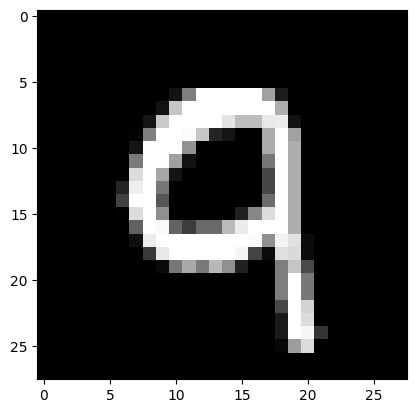

TEST PREDICTION 2
Prediction: [8]
Label:  8


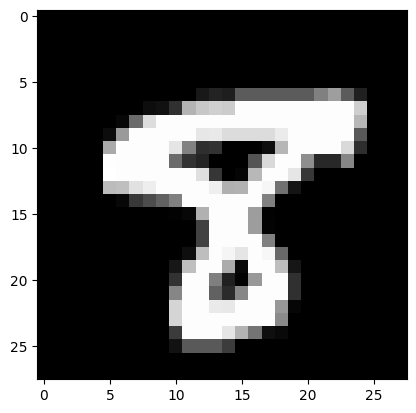

TEST PREDICTION 3
Prediction: [4]
Label:  4


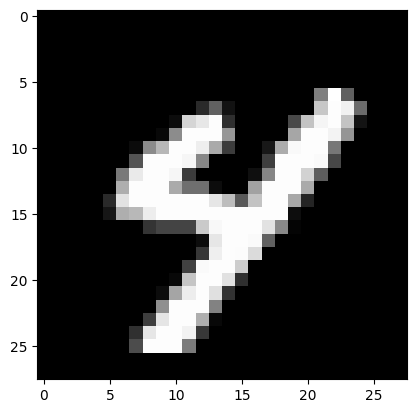

TEST PREDICTION 4
Prediction: [8]
Label:  8


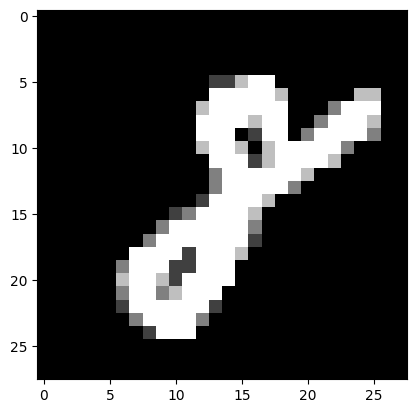

In [26]:
''' Testing phase '''

print("TEST PREDICTION 1")
test_prediction(0, W1, b1, W2, b2)
print("="*70)

print("TEST PREDICTION 2")
test_prediction(1, W1, b1, W2, b2)
print("="*70)

print("TEST PREDICTION 3")
test_prediction(2, W1, b1, W2, b2)
print("="*70)

print("TEST PREDICTION 4")
test_prediction(3, W1, b1, W2, b2)
print("="*70)

In [ ]:
''' Model accuracy validation '''

dev_predictions = make_prediction(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, y_dev)
print(f"Model Accuracy: {get_accuracy(dev_predictions, y_dev) * 100:.2f}%")

Model Accuracy: 87.10%
